In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import sys
sys.path.append('../src/')
from probabilistic_model import ProbabilisticModel

In [2]:
def load_data(model, state):
    '''Method for loading descriptors for the provided model and state.'''
    acsf = np.load(f'../data/descriptors/neigh_16/{model}_{state}_acsf.npy')
    stein = np.load(f'../data/descriptors/neigh_16/{model}_{state}_stein.npy')
    X = np.hstack((acsf, stein))
    return X

In [3]:
def visualize_features(desc, model, hda_desc, lda_desc):
    '''
        Method for visualizing distribution of a state's features
        along the features chosen by the classification model for
        comparison to HDA and LDA distributions.
    '''
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.linewidth'] = 1.1
    fig, axs = plt.subplots(4,5,figsize=(12.0,12.0))
    axs = axs.reshape(-1)
    for feat_idx, feat in enumerate(model.ood_feat):
        if feat_idx < 20:
            candidate = desc[:,feat]
            hda = hda_desc[:,feat]
            lda = lda_desc[:,feat]
            axs[feat_idx].hist(candidate, bins=30, density=True, color='gray', alpha=0.5, label='Trial')
            axs[feat_idx].hist(hda, bins=30, density=True, color='blue', alpha=0.5, label='HDA')
            axs[feat_idx].hist(lda, bins=30, density=True, color='red', alpha=0.5, label='LDA')
            axs[feat_idx].spines[['top', 'right']].set_visible(False)
            axs[feat_idx].set_xlabel(f'Desc #{feat_idx + 1}')
            # axs[feat_idx].set_ylabel('')
            axs[feat_idx].set_yticks([])
    plt.tight_layout()
    plt.show()

In [4]:
# Load model for evaluation.
MODEL = 'mbpol'
models = [
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_5_include_0.999.pkl', 'rb')),
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_10_include_0.999.pkl', 'rb')),
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_20_include_0.999.pkl', 'rb')),
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_30_include_0.999.pkl', 'rb')),
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_50_include_0.999.pkl', 'rb')),
    pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_out_120_include_0.999.pkl', 'rb')),
]
out_feat = [5, 10, 20, 30, 50, 120]

In [5]:
hda_desc = load_data(MODEL, 'hda')
lda_desc = load_data(MODEL, 'lda')

In [6]:
# Make prediction on HDA (baseline).
hda_desc = load_data(MODEL, 'hda')
for m_idx, m in enumerate(models):
    y = m.predict(hda_desc)
    accuracy = len(np.argwhere(y == 0).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

5-feature Outlier Accuracy: 0.991
10-feature Outlier Accuracy: 0.990
20-feature Outlier Accuracy: 0.987
30-feature Outlier Accuracy: 0.985
50-feature Outlier Accuracy: 0.984
120-feature Outlier Accuracy: 0.984


In [7]:
# Make prediction on LDA (baseline).
lda_desc = load_data(MODEL, 'lda')
for m_idx, m in enumerate(models):
    y = m.predict(lda_desc)
    accuracy = len(np.argwhere(y == 1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

5-feature Outlier Accuracy: 0.993
10-feature Outlier Accuracy: 0.993
20-feature Outlier Accuracy: 0.992
30-feature Outlier Accuracy: 0.990
50-feature Outlier Accuracy: 0.989
120-feature Outlier Accuracy: 0.989


5-feature Outlier Accuracy: 1.000
10-feature Outlier Accuracy: 1.000
20-feature Outlier Accuracy: 1.000
30-feature Outlier Accuracy: 1.000
50-feature Outlier Accuracy: 1.000
120-feature Outlier Accuracy: 1.000


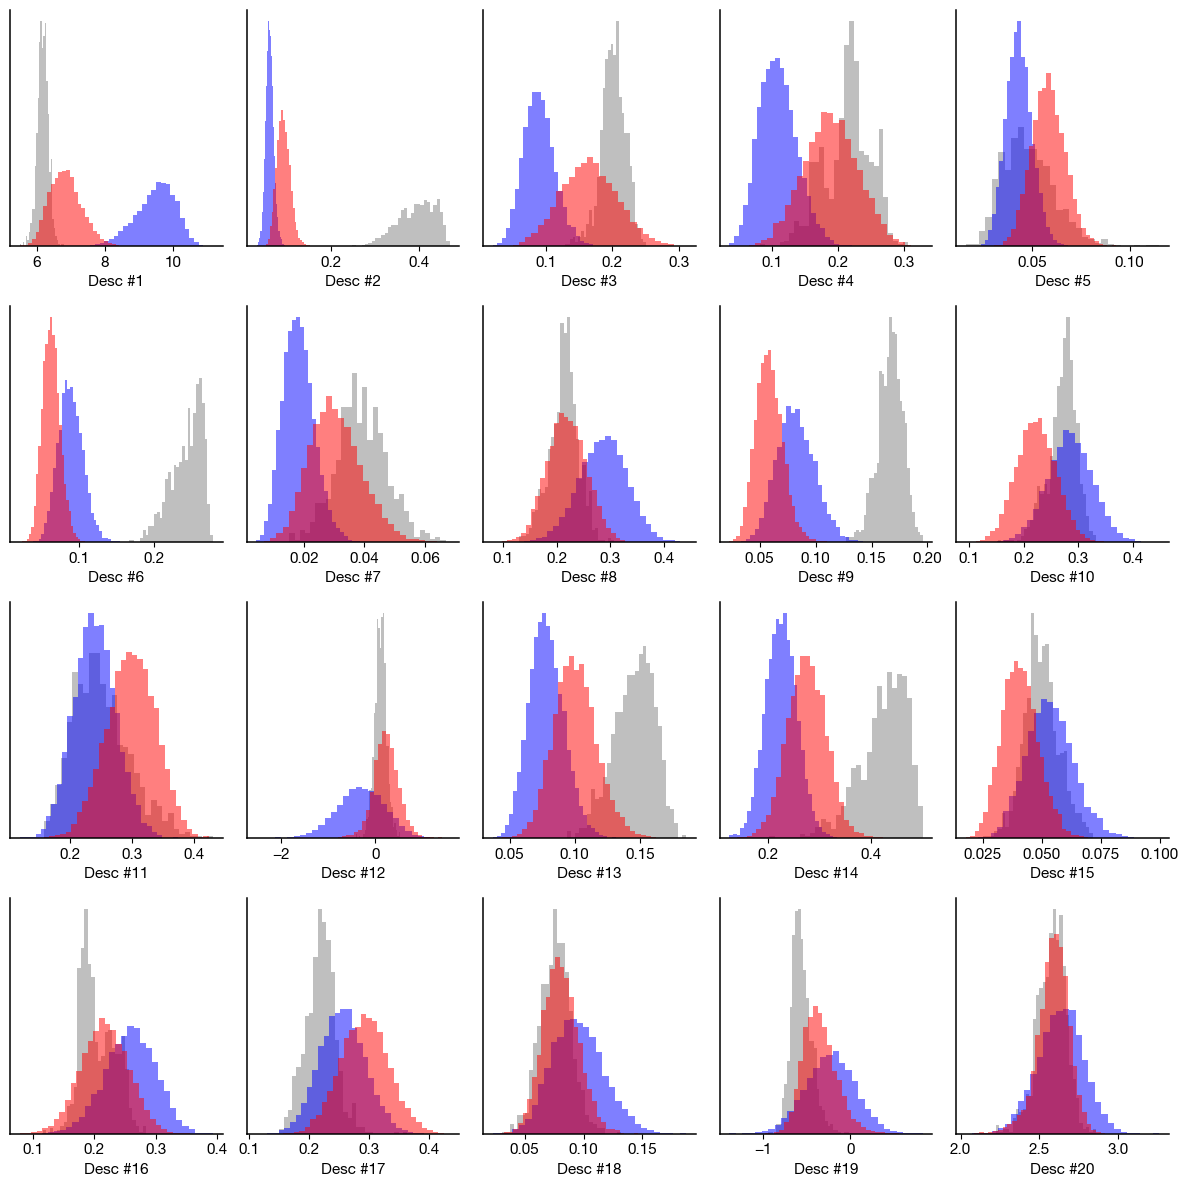

In [8]:
# Make prediction on hexagonal ice (baseline).
desc = load_data(MODEL, 'ice')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 1.000
10-feature Outlier Accuracy: 1.000
20-feature Outlier Accuracy: 1.000
30-feature Outlier Accuracy: 1.000
50-feature Outlier Accuracy: 1.000
120-feature Outlier Accuracy: 1.000


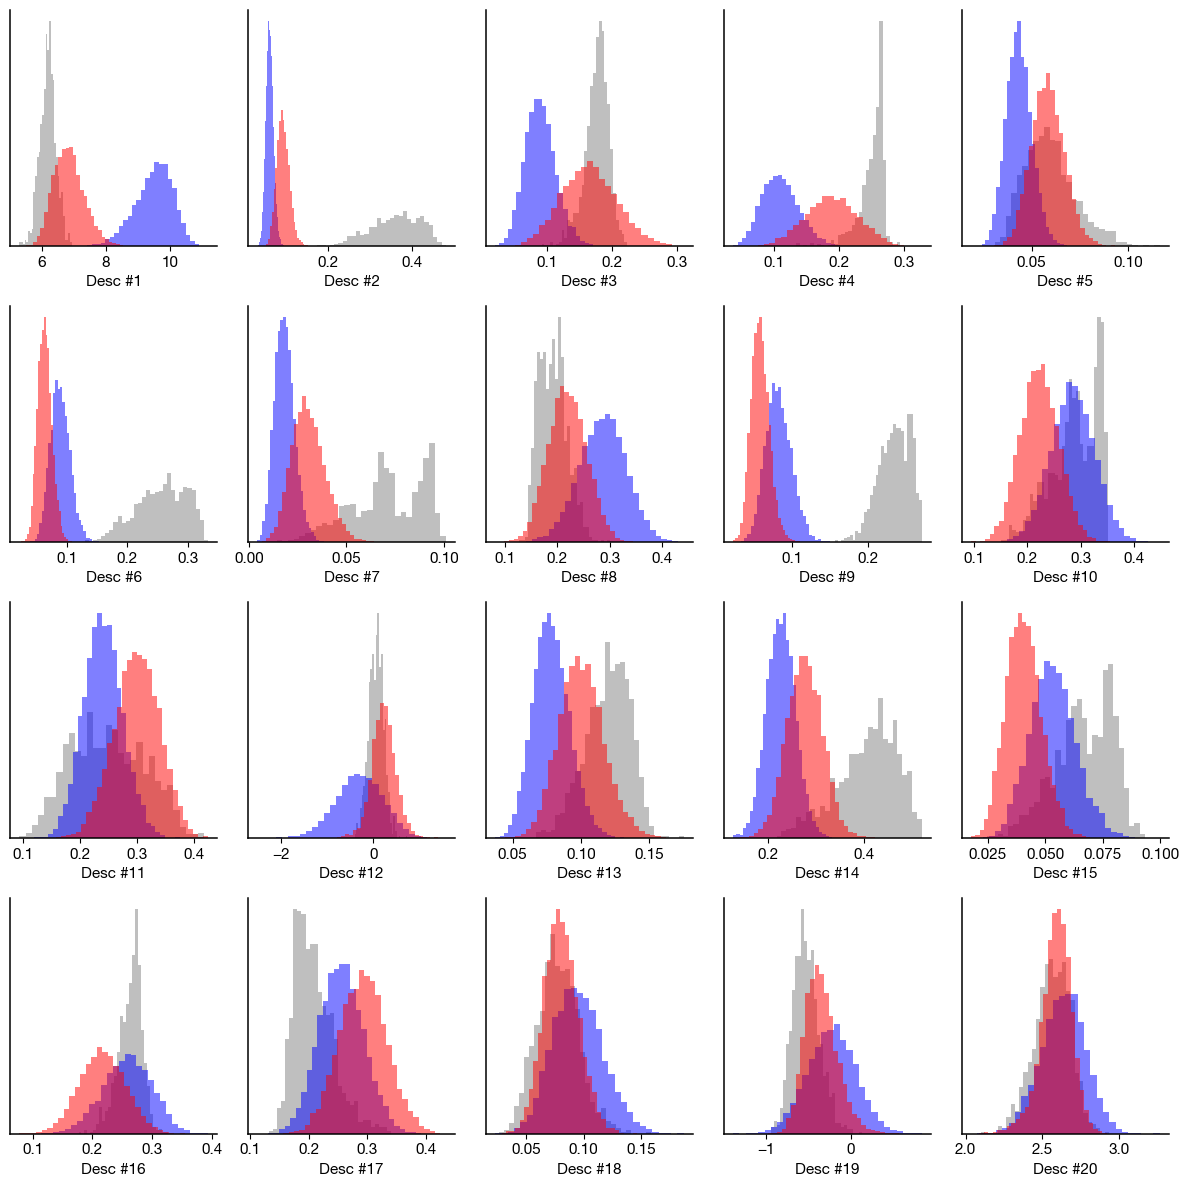

In [9]:
# Make prediction on ice01c.
desc = load_data(MODEL, 'ice01c')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.000
10-feature Outlier Accuracy: 0.000
20-feature Outlier Accuracy: 0.007
30-feature Outlier Accuracy: 0.110
50-feature Outlier Accuracy: 0.122
120-feature Outlier Accuracy: 0.122


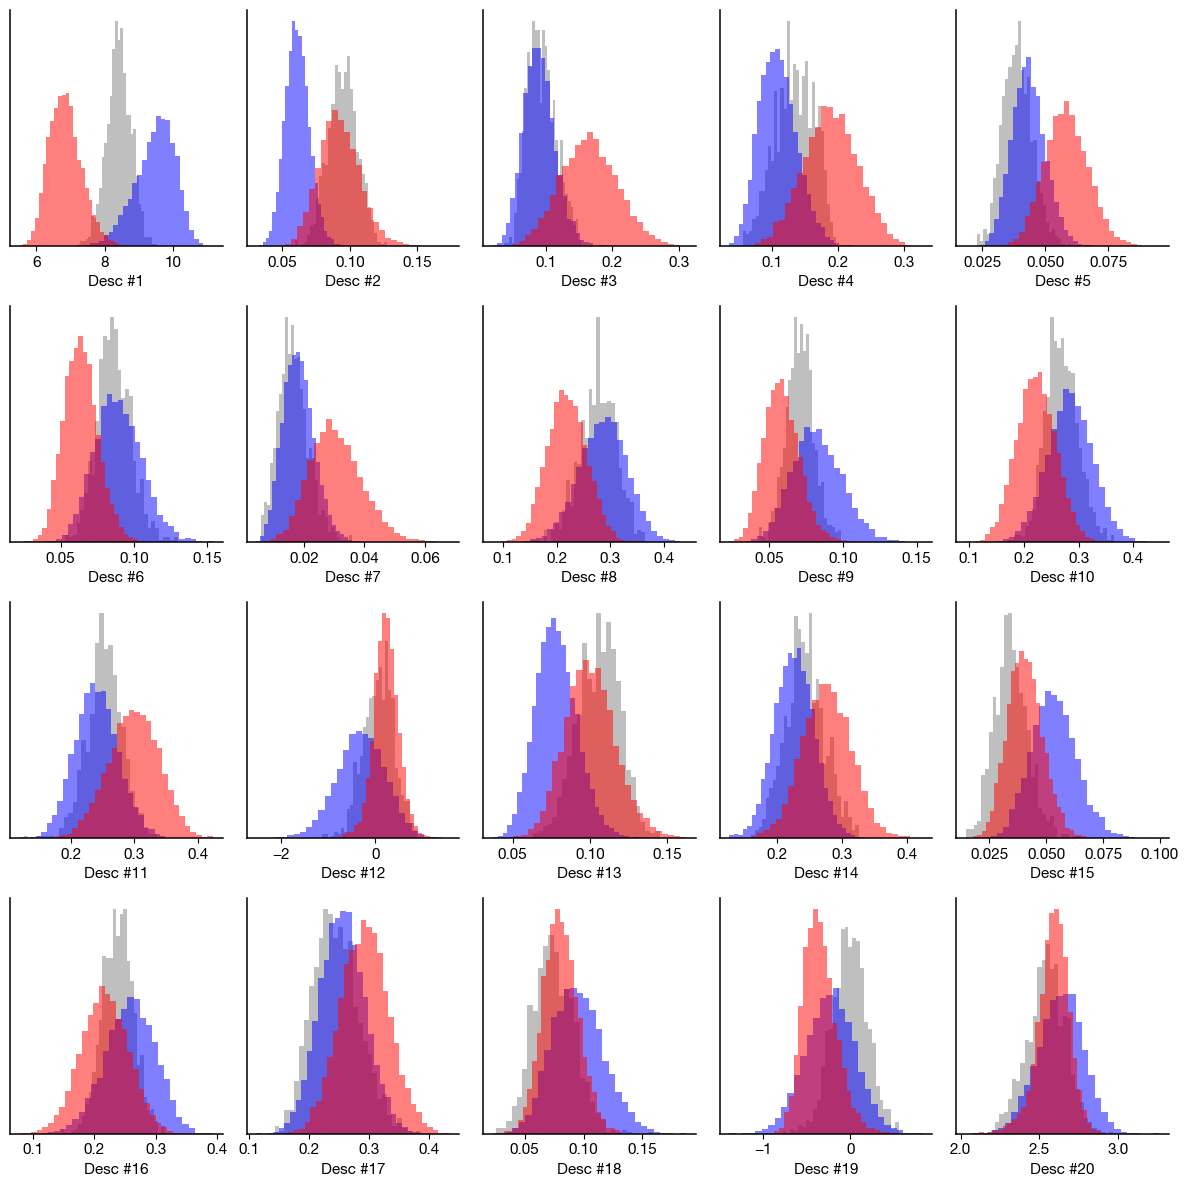

In [10]:
# Make prediction on ice02.
desc = load_data(MODEL, 'ice02')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.009
10-feature Outlier Accuracy: 0.017
20-feature Outlier Accuracy: 0.931
30-feature Outlier Accuracy: 0.931
50-feature Outlier Accuracy: 0.933
120-feature Outlier Accuracy: 0.933


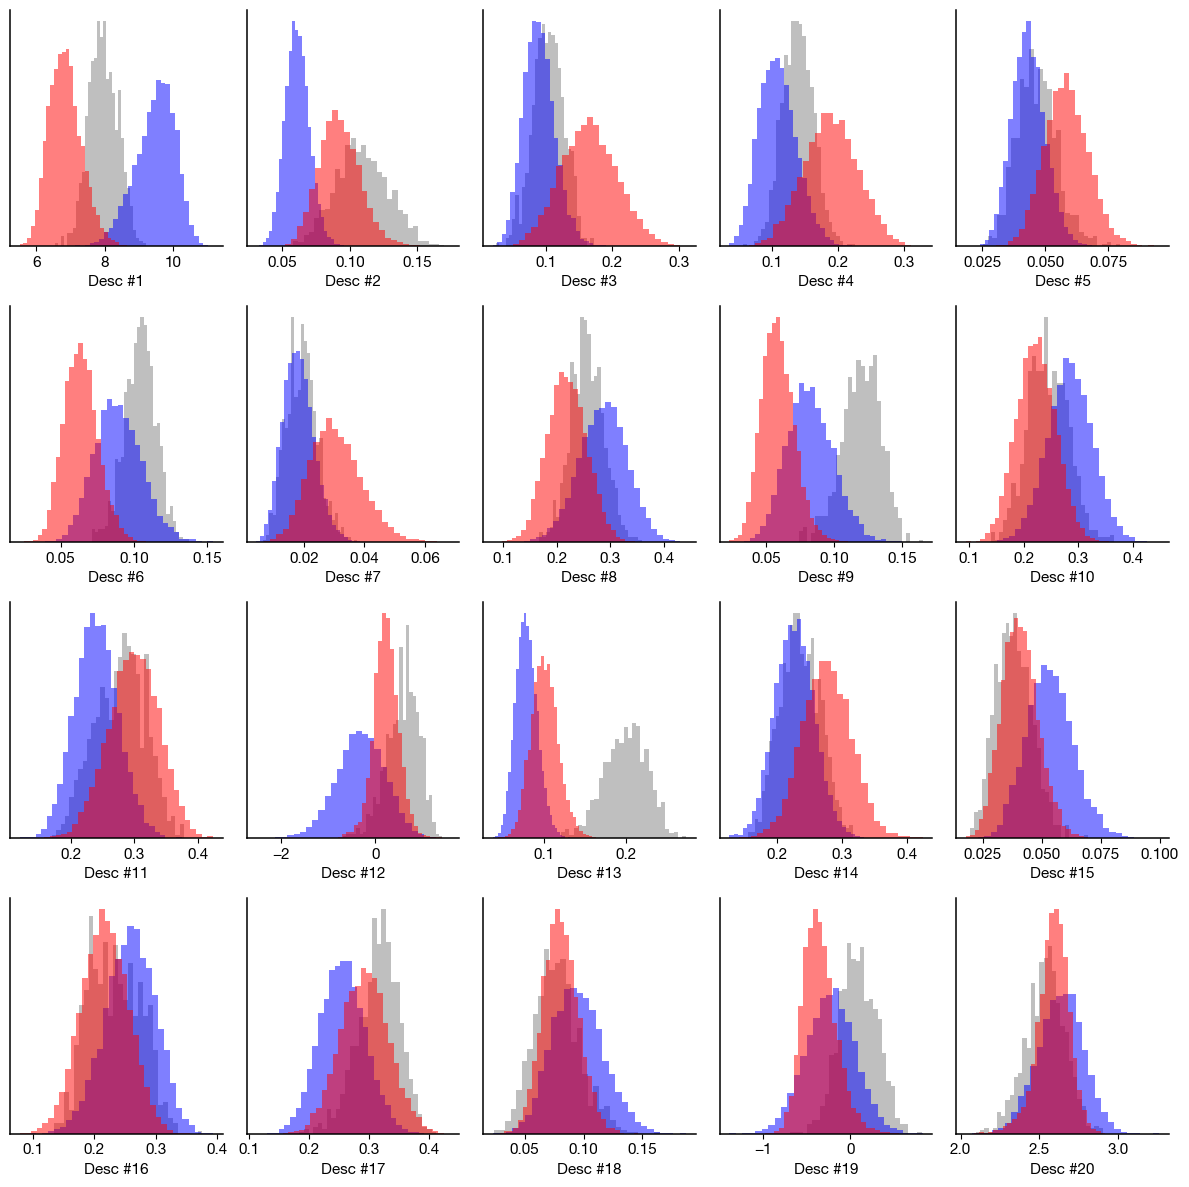

In [11]:
# Make prediction on ice03.
desc = load_data(MODEL, 'ice03')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.012
10-feature Outlier Accuracy: 0.012
20-feature Outlier Accuracy: 0.019
30-feature Outlier Accuracy: 0.021
50-feature Outlier Accuracy: 0.033
120-feature Outlier Accuracy: 0.033


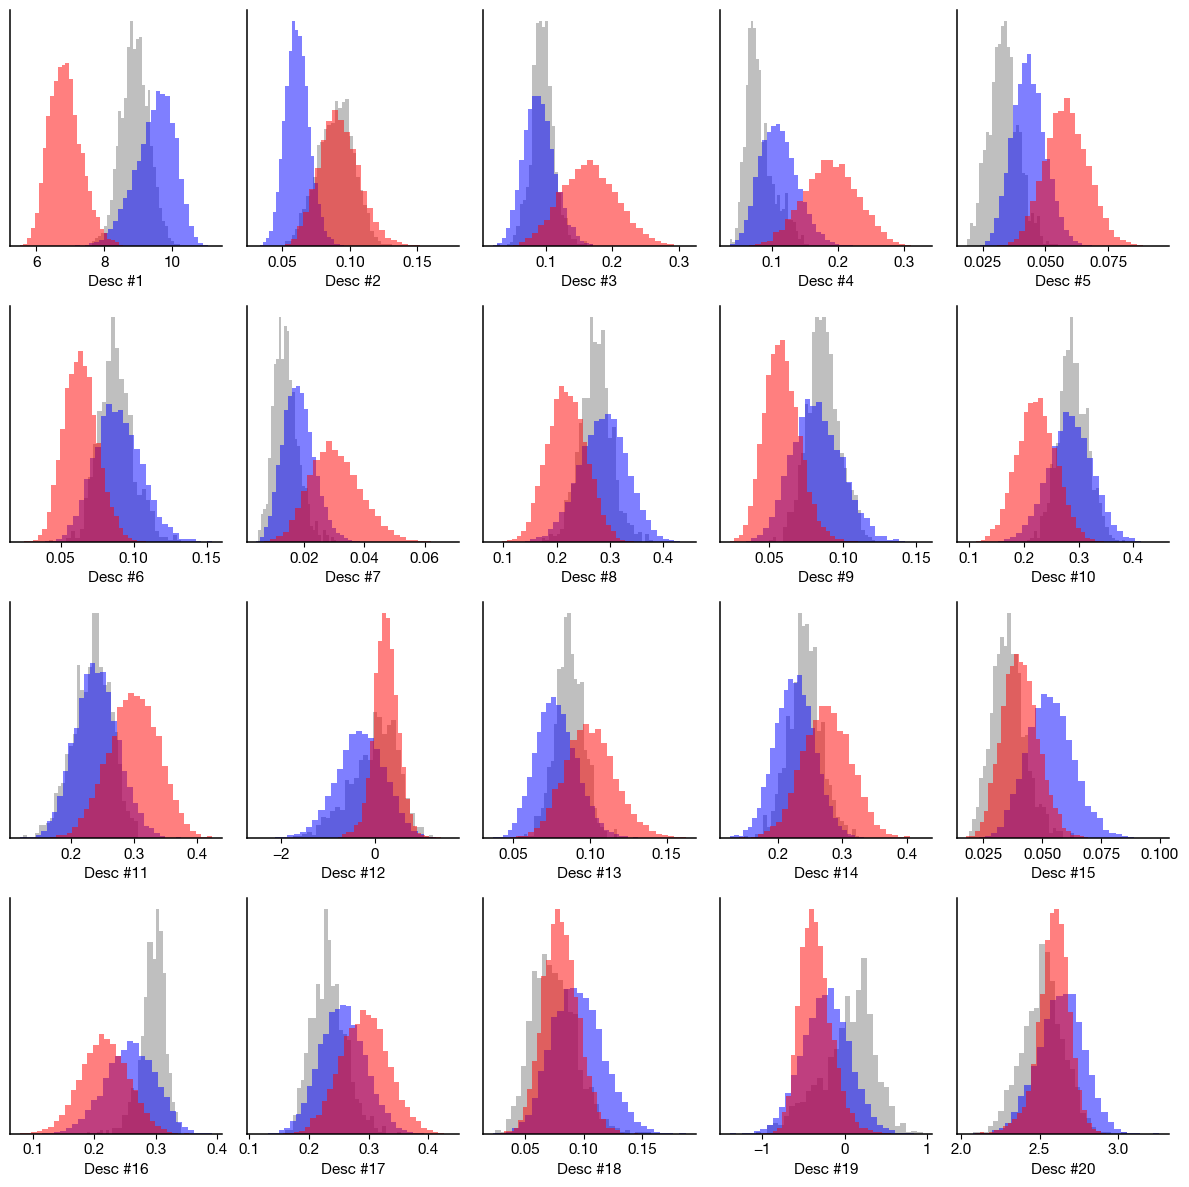

In [12]:
# Make prediction on ice04.
desc = load_data(MODEL, 'ice04')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.003
10-feature Outlier Accuracy: 0.830
20-feature Outlier Accuracy: 0.871
30-feature Outlier Accuracy: 0.871
50-feature Outlier Accuracy: 0.872
120-feature Outlier Accuracy: 0.872


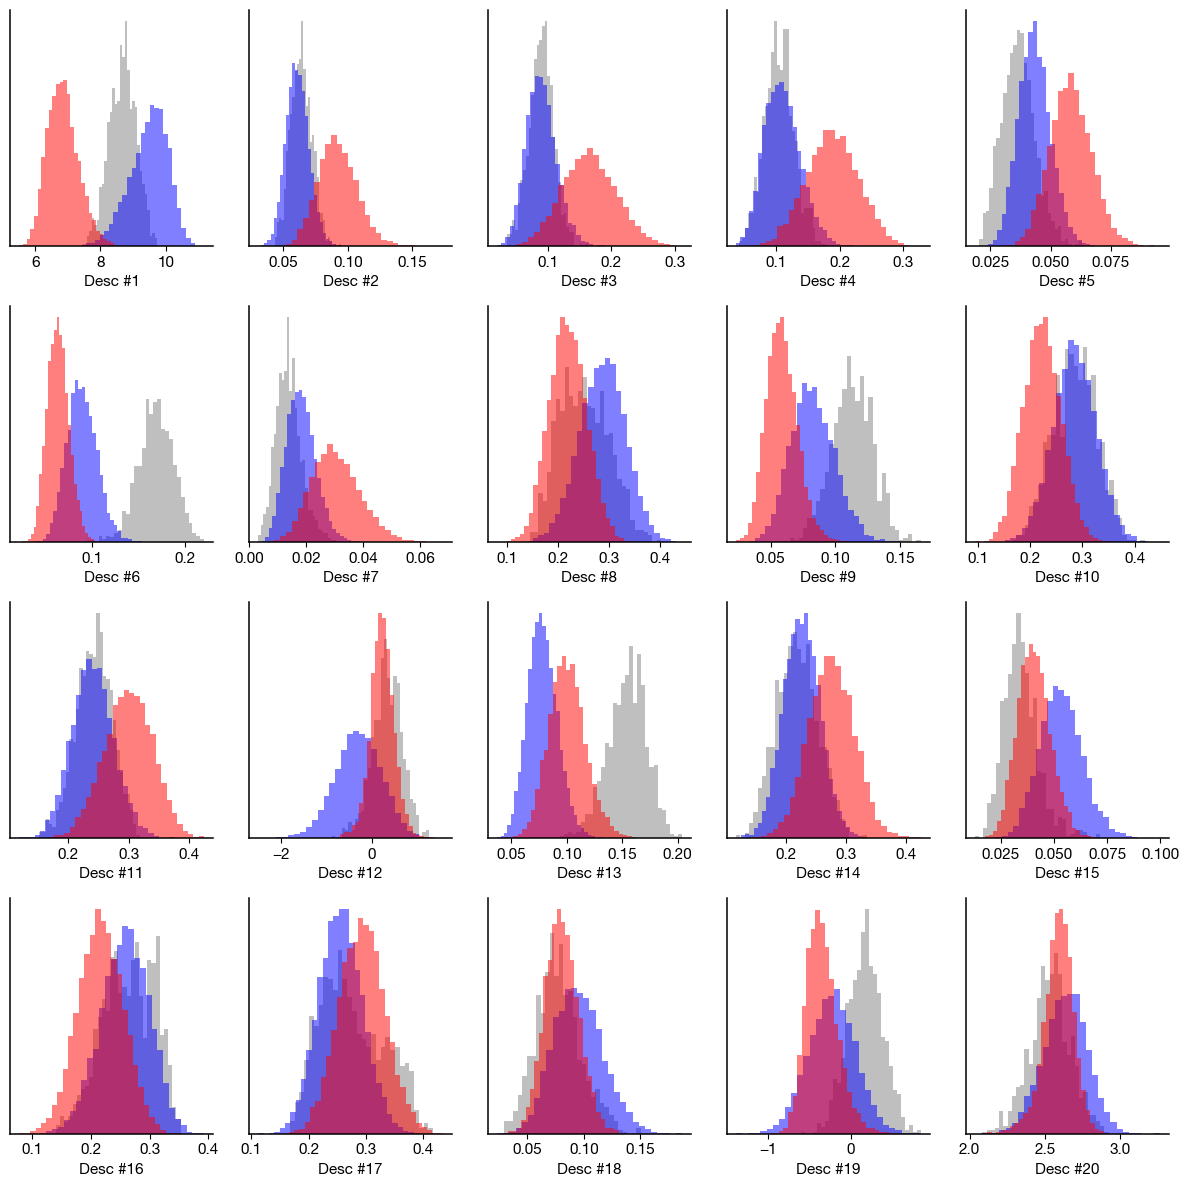

In [13]:
# Make prediction on ice05.
desc = load_data(MODEL, 'ice05')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.024
10-feature Outlier Accuracy: 0.041
20-feature Outlier Accuracy: 0.071
30-feature Outlier Accuracy: 0.108
50-feature Outlier Accuracy: 0.134
120-feature Outlier Accuracy: 0.134


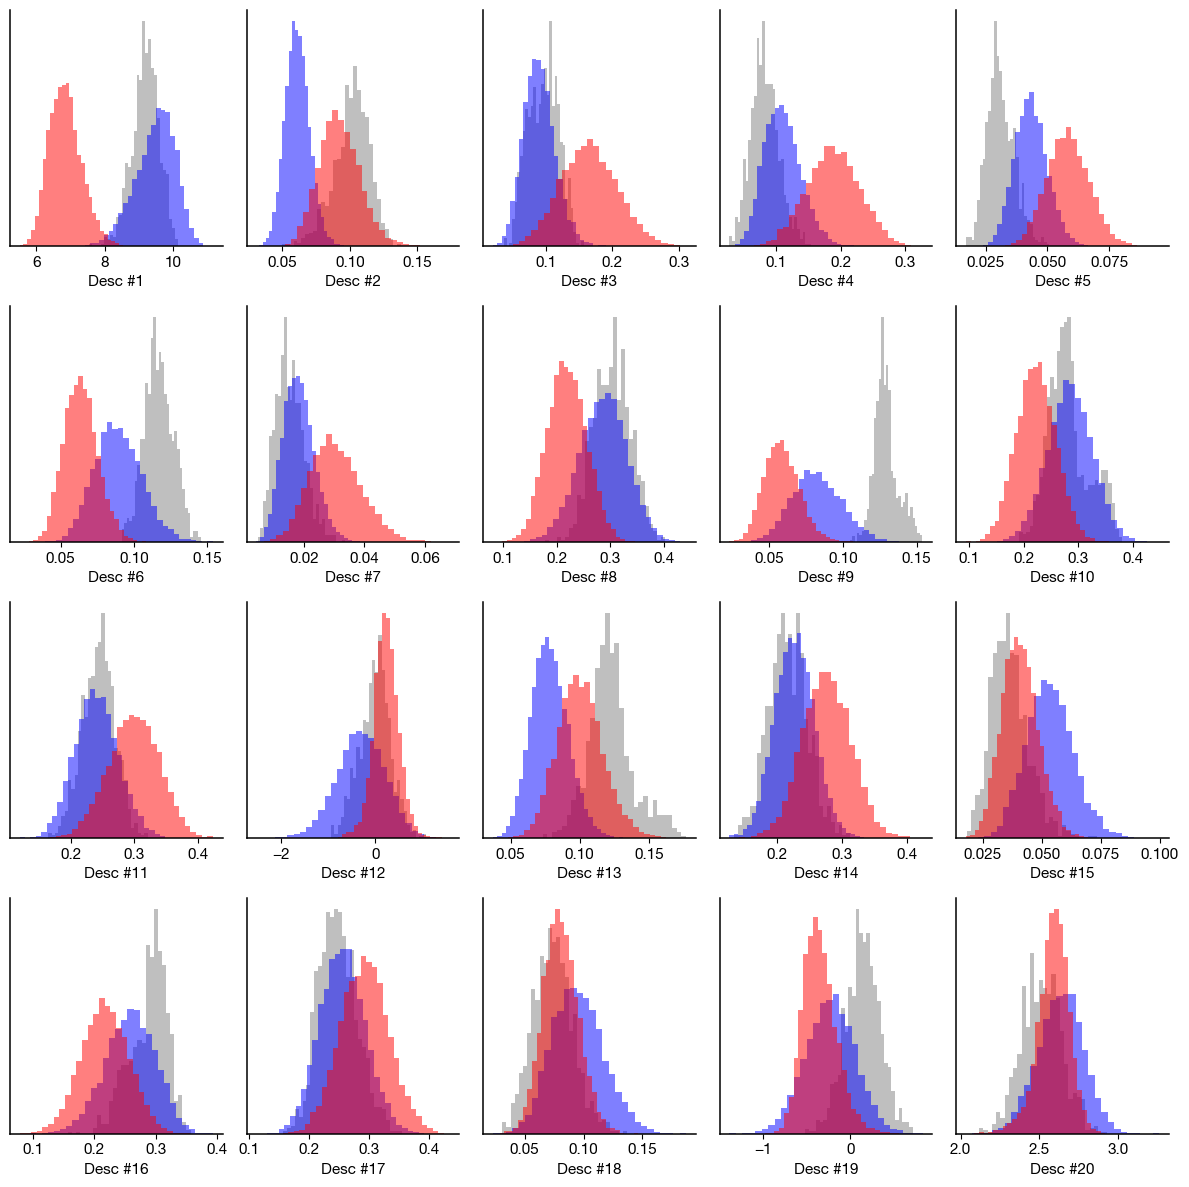

In [14]:
# Make prediction on ice06.
desc = load_data(MODEL, 'ice06')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 1.000
10-feature Outlier Accuracy: 1.000
20-feature Outlier Accuracy: 1.000
30-feature Outlier Accuracy: 1.000
50-feature Outlier Accuracy: 1.000
120-feature Outlier Accuracy: 1.000


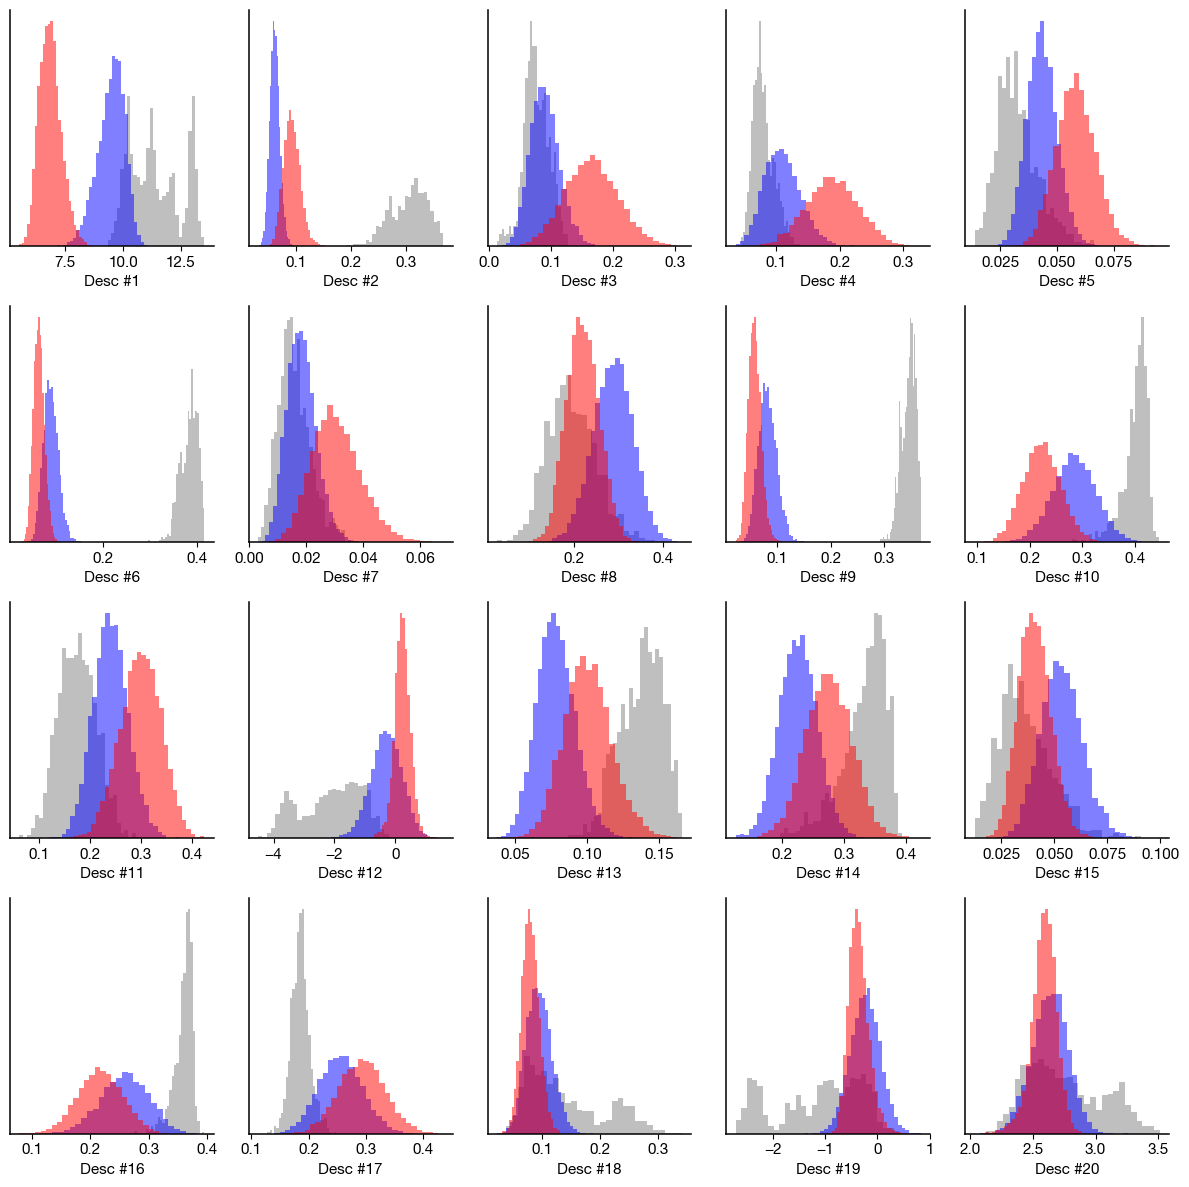

In [15]:
# Make prediction on ice07.
desc = load_data(MODEL, 'ice07')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 1.000
10-feature Outlier Accuracy: 1.000
20-feature Outlier Accuracy: 1.000
30-feature Outlier Accuracy: 1.000
50-feature Outlier Accuracy: 1.000
120-feature Outlier Accuracy: 1.000


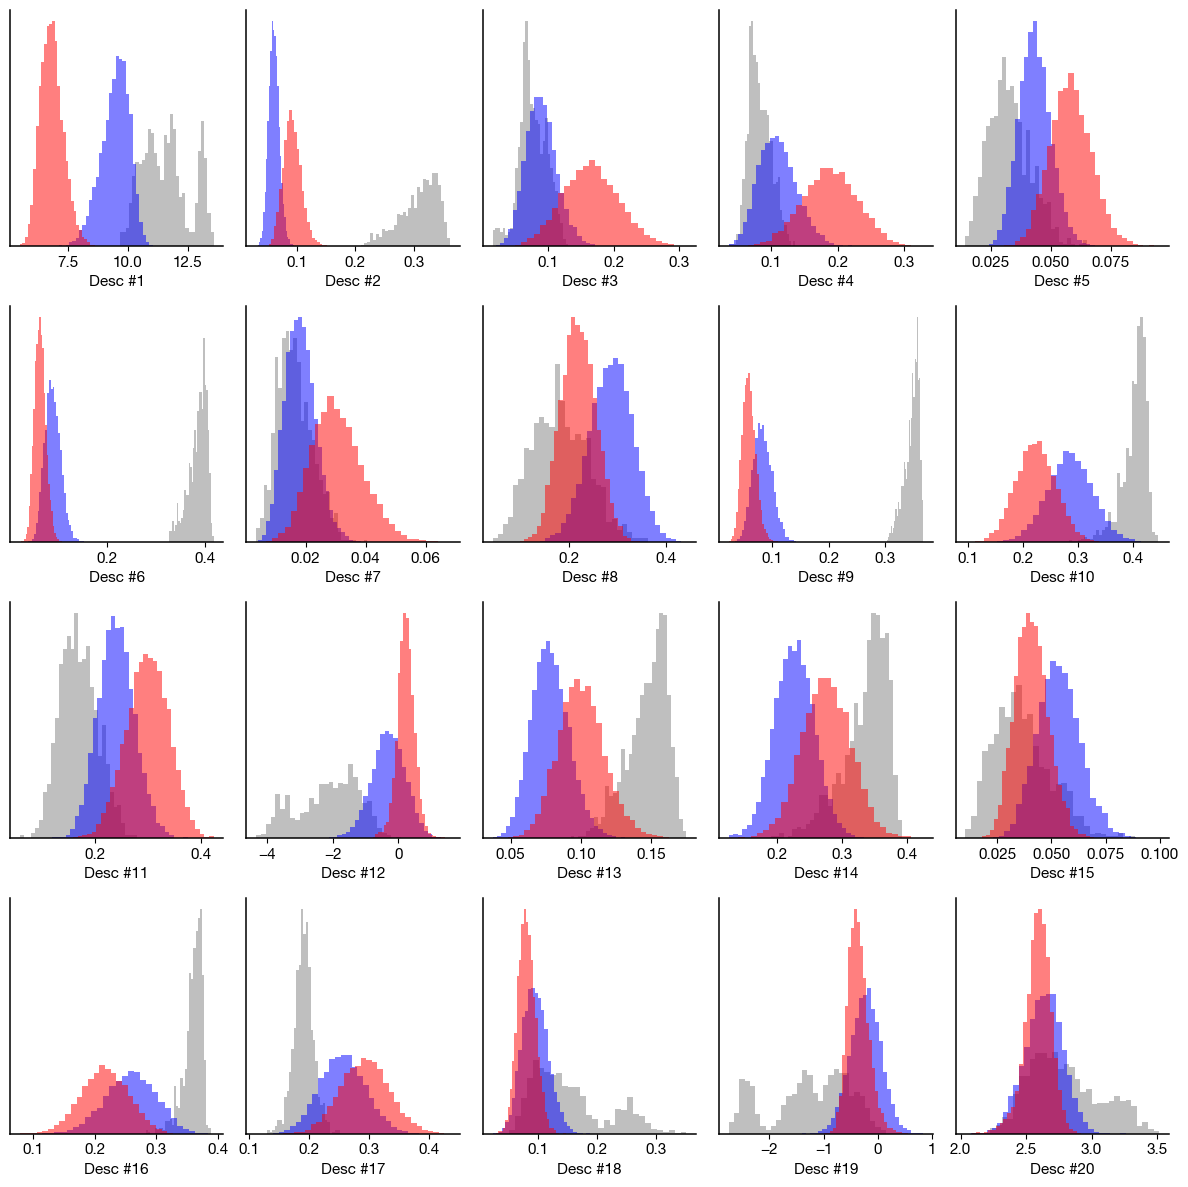

In [16]:
# Make prediction on ice08.
desc = load_data(MODEL, 'ice08')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.005
10-feature Outlier Accuracy: 0.270
20-feature Outlier Accuracy: 0.990
30-feature Outlier Accuracy: 0.990
50-feature Outlier Accuracy: 0.993
120-feature Outlier Accuracy: 0.993


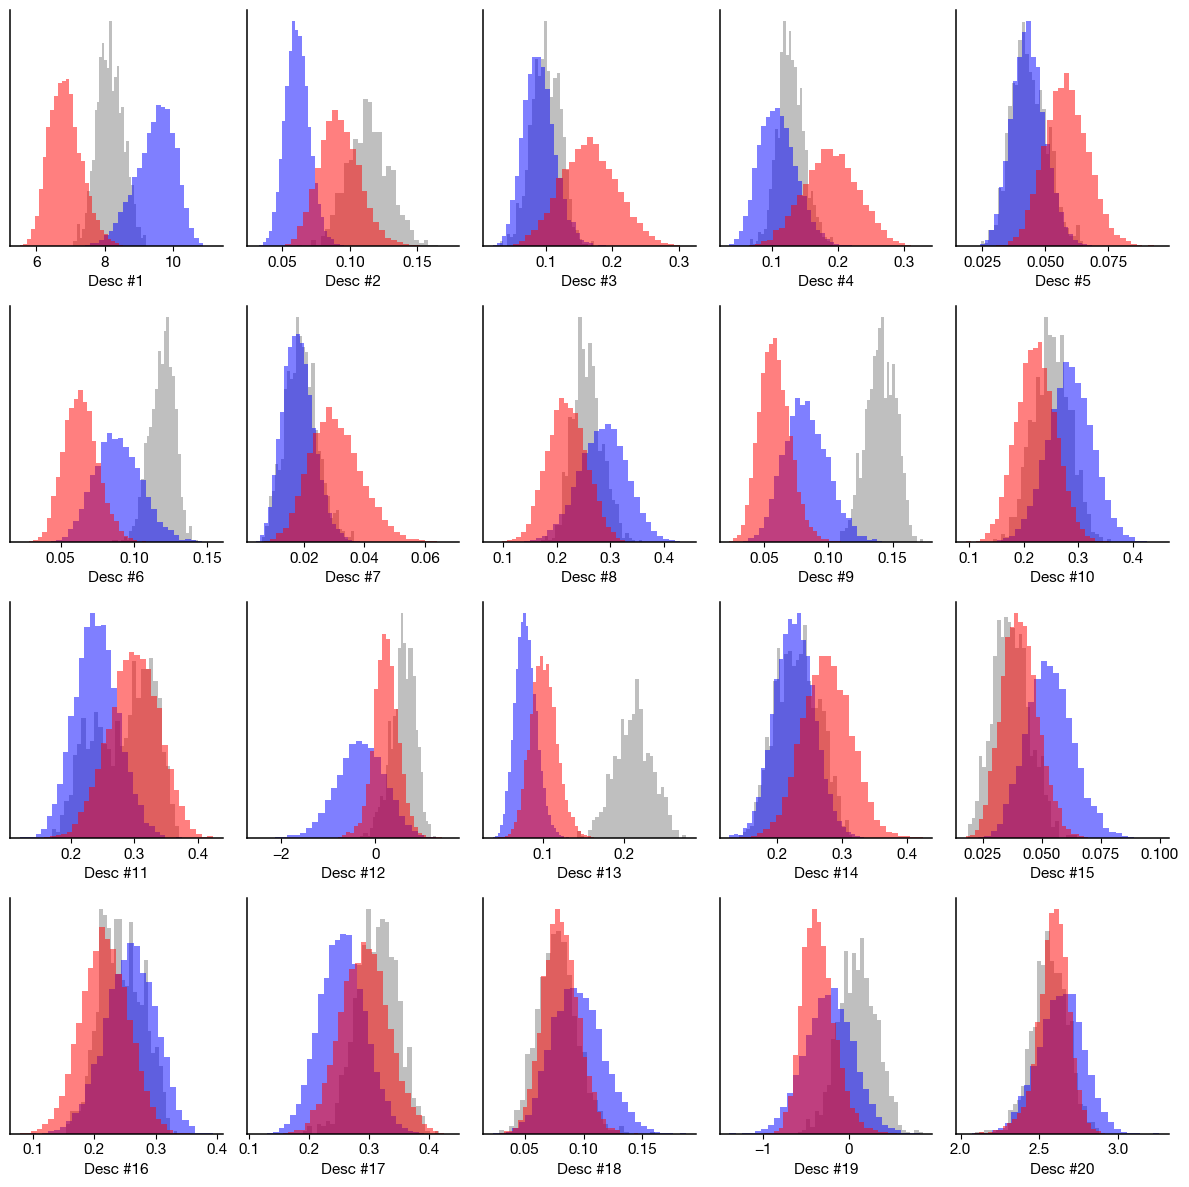

In [17]:
# Make prediction on ice09.
desc = load_data(MODEL, 'ice09')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.993
10-feature Outlier Accuracy: 0.993
20-feature Outlier Accuracy: 0.998
30-feature Outlier Accuracy: 0.998
50-feature Outlier Accuracy: 0.998
120-feature Outlier Accuracy: 0.998


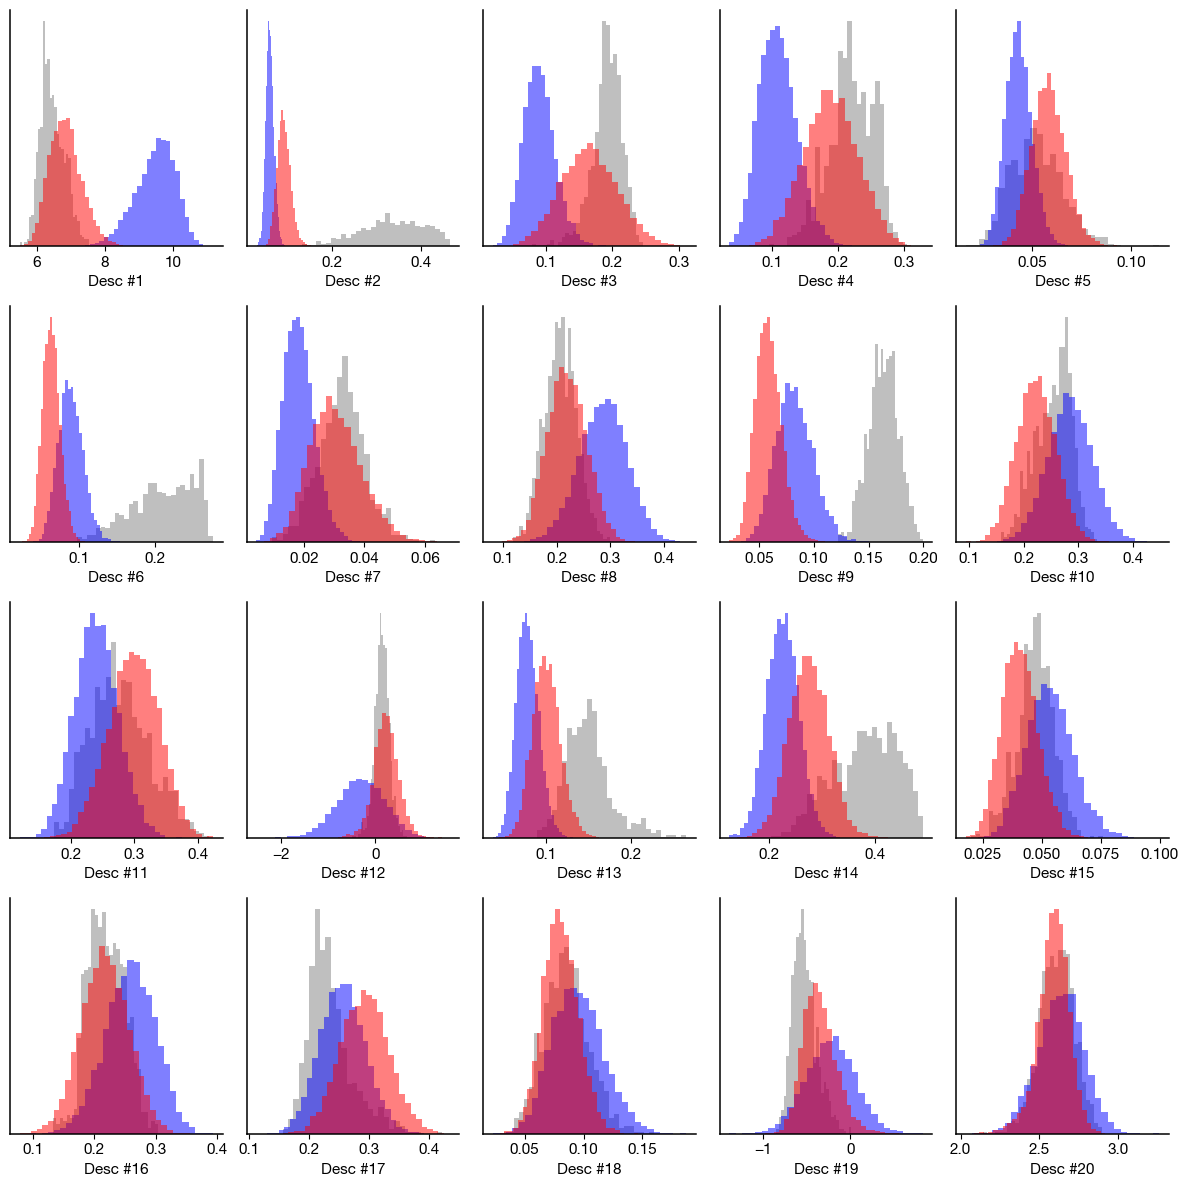

In [18]:
# Make prediction on ice11.
desc = load_data(MODEL, 'ice11')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.062
10-feature Outlier Accuracy: 0.987
20-feature Outlier Accuracy: 0.990
30-feature Outlier Accuracy: 0.990
50-feature Outlier Accuracy: 0.991
120-feature Outlier Accuracy: 0.991


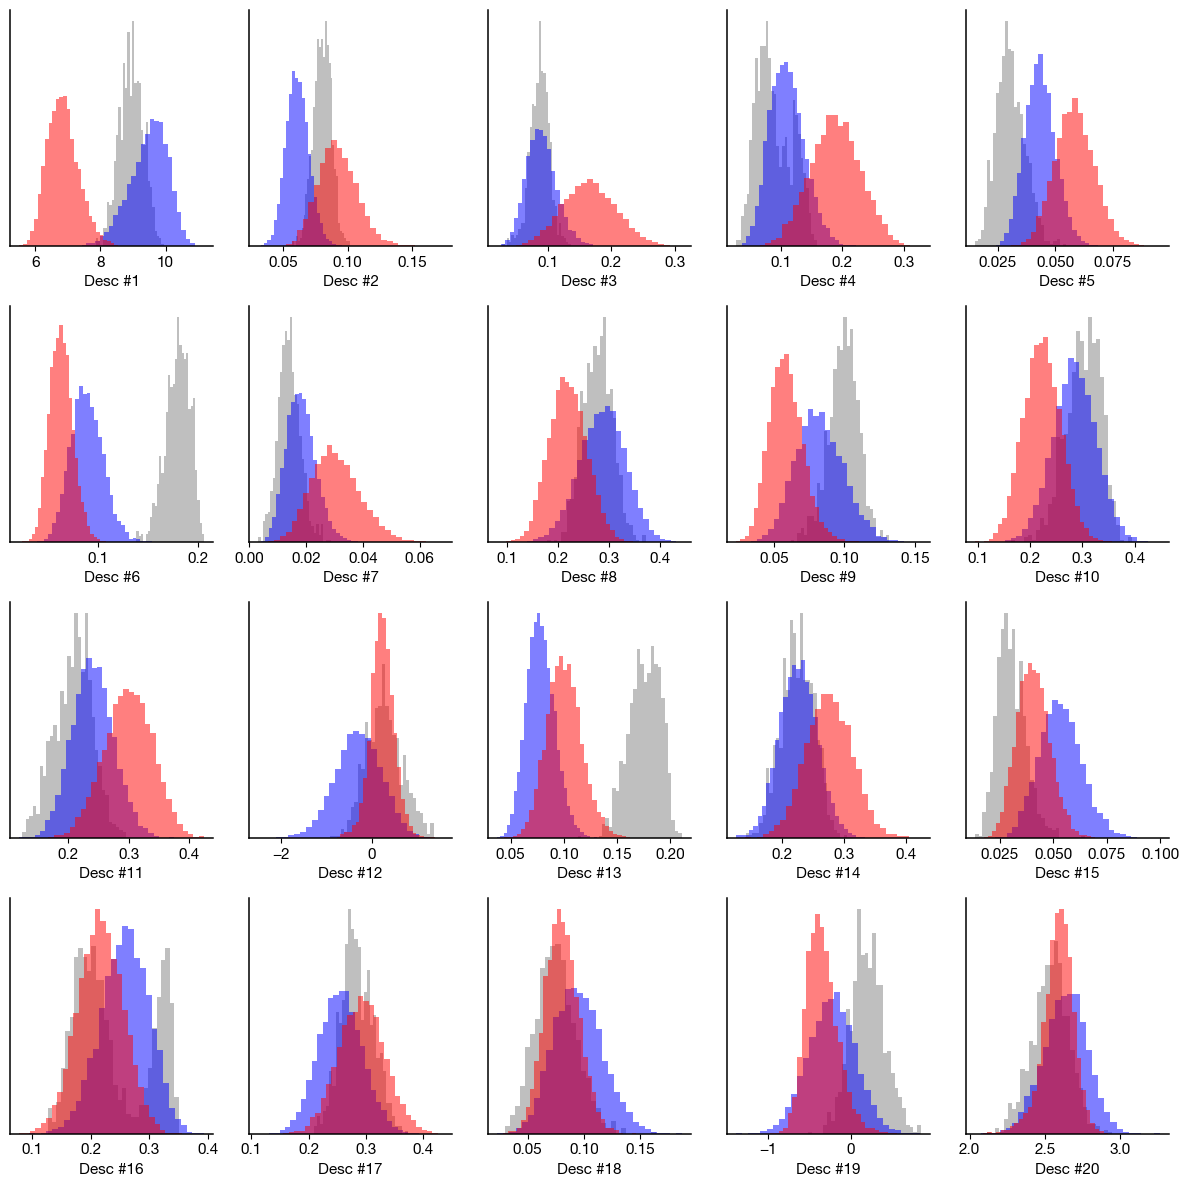

In [19]:
# Make prediction on ice12.
desc = load_data(MODEL, 'ice12')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.006
10-feature Outlier Accuracy: 0.687
20-feature Outlier Accuracy: 0.759
30-feature Outlier Accuracy: 0.759
50-feature Outlier Accuracy: 0.763
120-feature Outlier Accuracy: 0.763


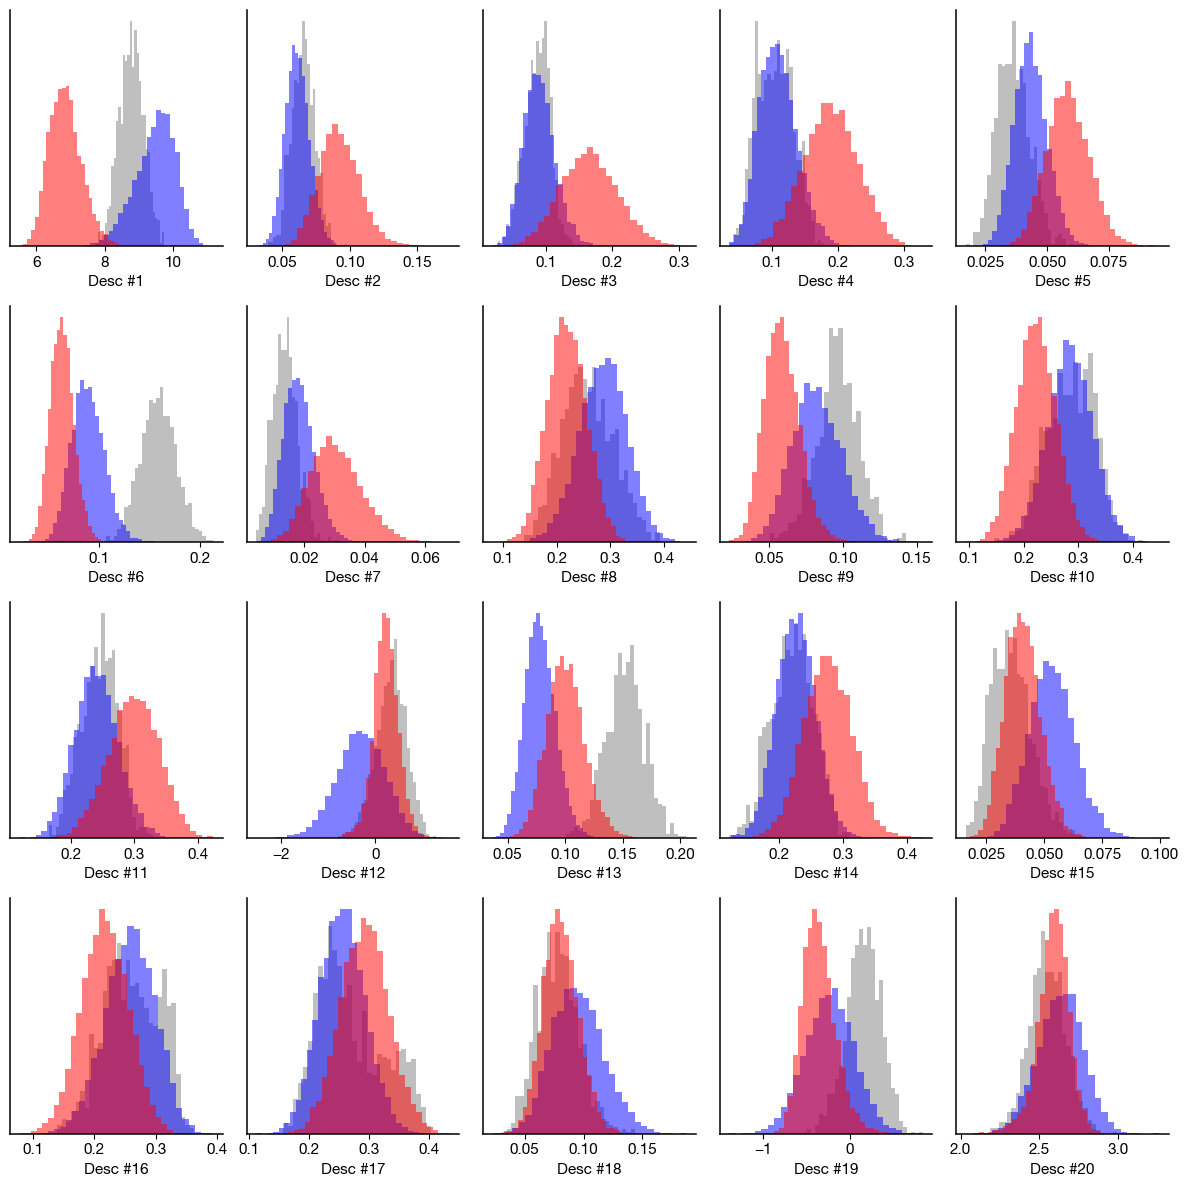

In [20]:
# Make prediction on ice13.
desc = load_data(MODEL, 'ice13')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.031
10-feature Outlier Accuracy: 0.984
20-feature Outlier Accuracy: 0.987
30-feature Outlier Accuracy: 0.987
50-feature Outlier Accuracy: 0.987
120-feature Outlier Accuracy: 0.987


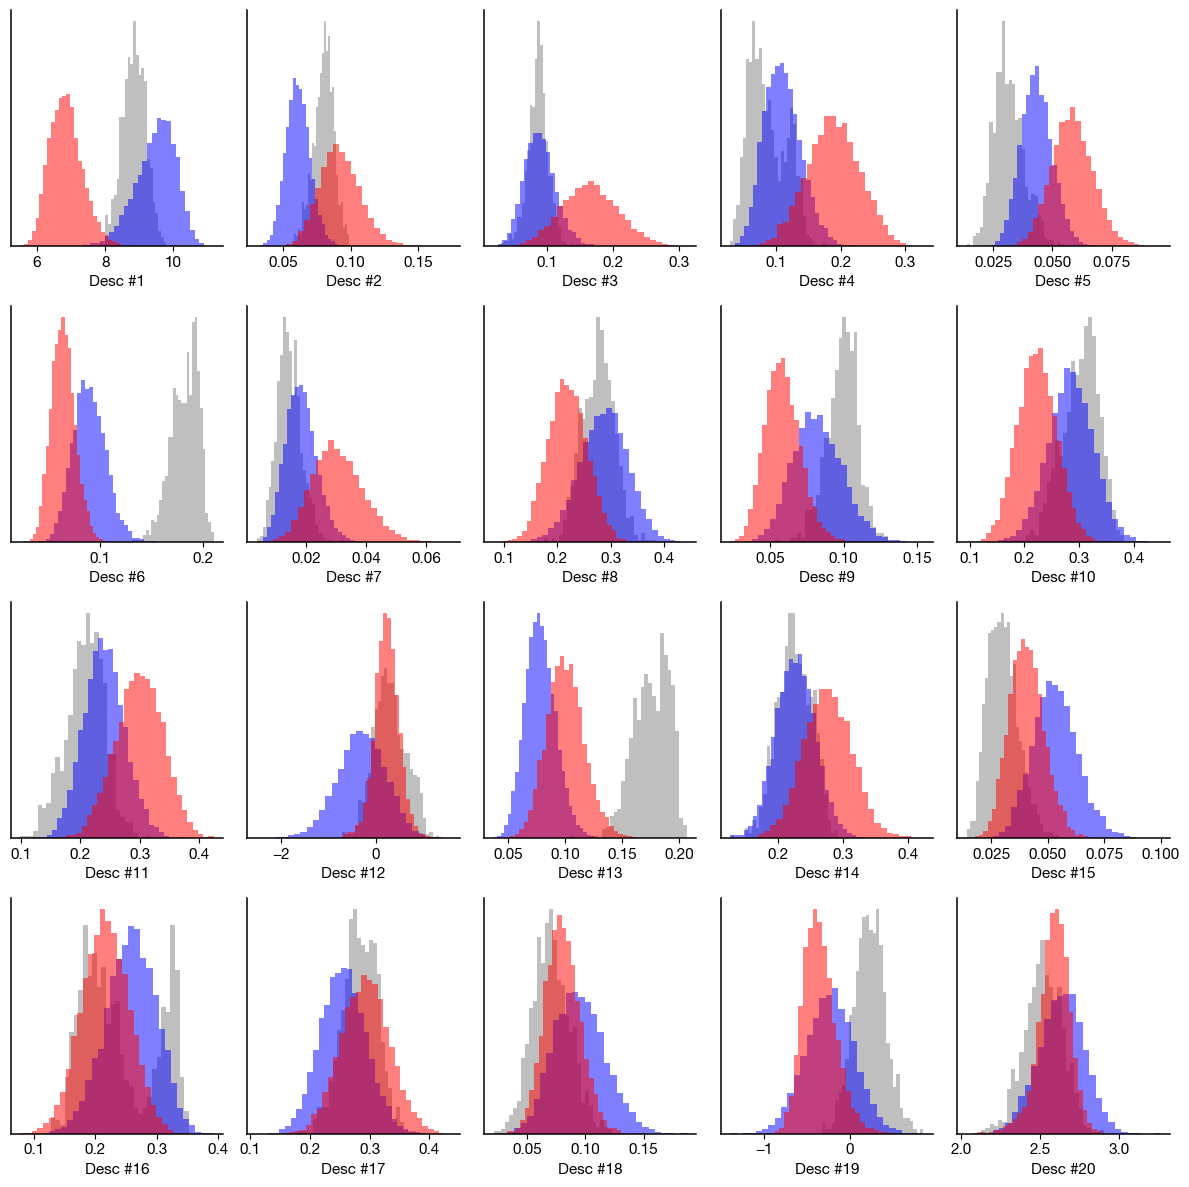

In [21]:
# Make prediction on ice14.
desc = load_data(MODEL, 'ice14')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.061
10-feature Outlier Accuracy: 0.107
20-feature Outlier Accuracy: 0.142
30-feature Outlier Accuracy: 0.193
50-feature Outlier Accuracy: 0.214
120-feature Outlier Accuracy: 0.214


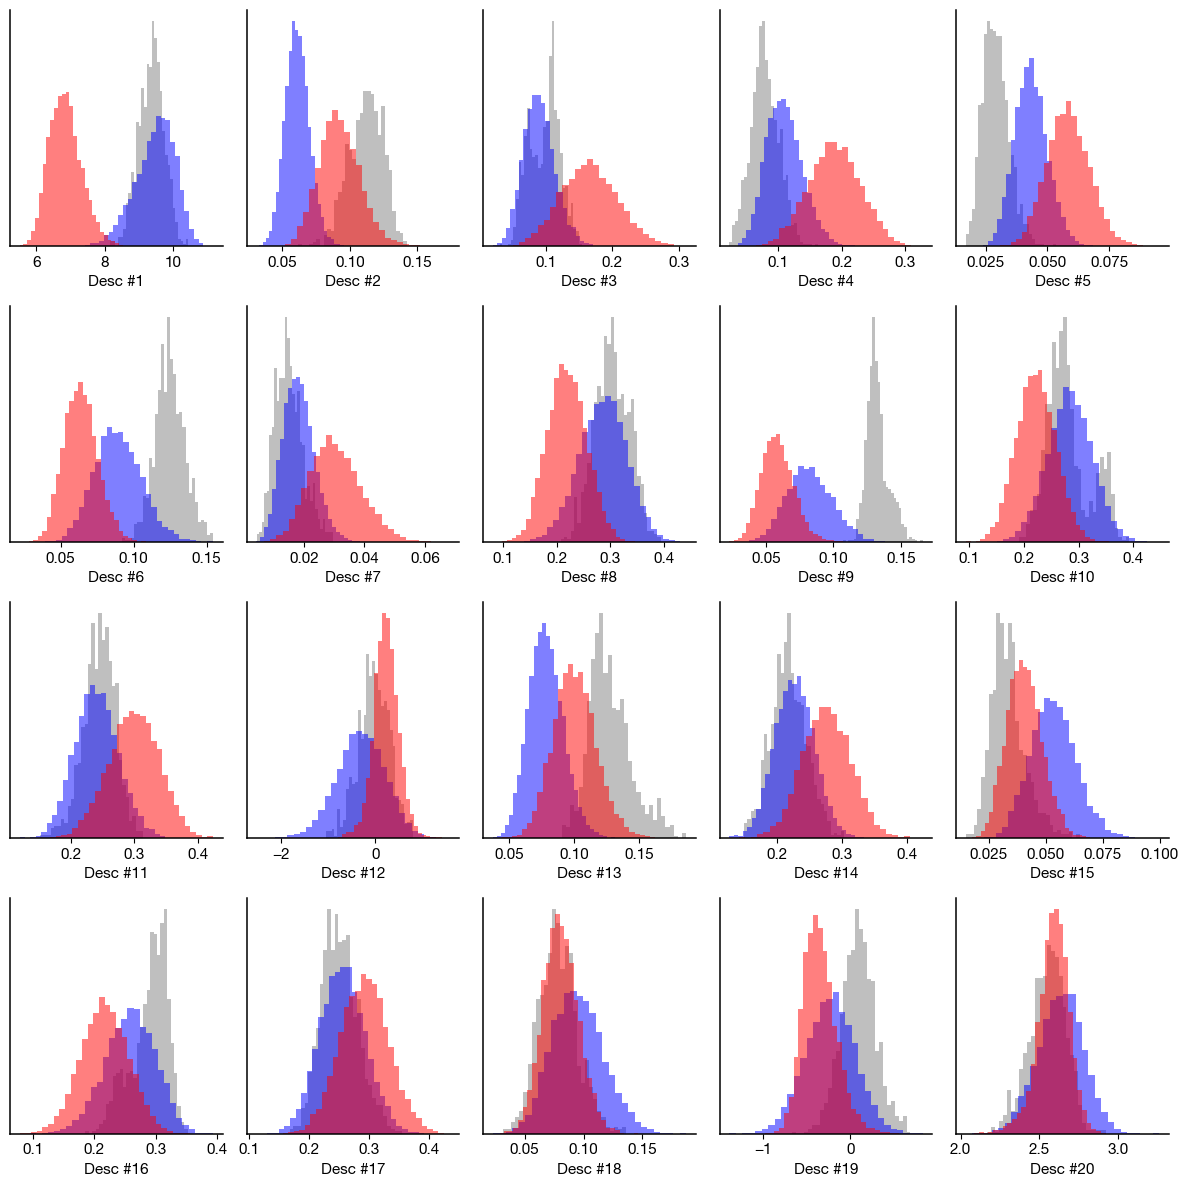

In [22]:
# Make prediction on ice15.
desc = load_data(MODEL, 'ice15')
for m_idx, m in enumerate(models):
    y = m.predict(desc)
    accuracy = len(np.argwhere(y == -1).reshape(-1)) / y.shape[0]
    print(f'{out_feat[m_idx]}-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, models[2], hda_desc, lda_desc)